# Step 1 — First Improvements: Better Optimizer and GPU Tuning

**CUDA-Q QAOA GPU-Optimization Learning Path · notebook 1 of 4 (Read-only)**

This notebook is **based on notebook 00**: the same 16-qubit region-coloring problem, the same
circuit, the same budget — with the tutorial's first clearly named improvements applied.

1. **A better optimizer.** Notebook 00 used COBYLA (careful steps inside a shrinking trust
   region). Here it is replaced with **Nelder–Mead**, which walks a small triangle of guesses
   downhill and, on this energy landscape, finds much deeper minima with the same 50-evaluation
   budget. The results cell shows the improvement directly against notebook 00's number.
2. **GPU tuning.** The `nvidia` simulator reads environment variables at import time:
   - `CUDAQ_FUSION_MAX_QUBITS = "3"` — *gate fusion*: merge several small neighboring gates into
     one bigger operation so the GPU makes fewer passes over the state.
   - `CUDAQ_FUSION_NUM_HOST_THREADS = "4"` — how many CPU helper threads prepare the circuit.

**Important:** Because the variables are read when CUDA-Q is imported, they sit in the very first lines of the
first code cell — restart the kernel if you change them.

In [1]:
# Cell 1 — GPU settings FIRST (read at import time), then the same problem as notebook 00.
import os
os.environ["CUDAQ_FUSION_MAX_QUBITS"] = "3"        # gate fusion: merge small gates, fewer GPU passes
os.environ["CUDAQ_FUSION_NUM_HOST_THREADS"] = "4"  # CPU helper threads that prepare the circuit

import sys, time
import matplotlib.pyplot as plt
import helpers as hp
import cudaq            # <- the settings above are picked up here

cudaq.set_random_seed(1234)
cudaq.set_target("nvidia", option="fp32")
print(f"CUDA-Q {cudaq.__version__.split()[2]}   Python {sys.version.split()[0]}")

taiwan = hp.load_map()
NODES = hp.REGION_ORDER              # ["North", "Central", "South", "East"]
EDGES = taiwan["region_edges"]       # the same 5 neighboring pairs as notebook 00
K = 4                                # colors
A, B = 4.0, 1.0                      # penalty weights, as in notebook 00
N = len(NODES) * K                   # 16 qubits

coeffs, qubo_offset = hp.build_qubo(NODES, EDGES, K, A, B)
H, terms, offset = hp.qubo_to_spin(coeffs, qubo_offset)
zq, zc, zz1, zz2, zzc = hp.terms_to_lists(terms)
print(f"same problem as notebook 00, rebuilt from the same data: {N} qubits, "
      f"{len(terms['z'])} Z + {len(terms['zz'])} ZZ terms, offset {offset}")

CUDA-Q amd64-cu13-0.15.0   Python 3.12.3
same problem as notebook 00, rebuilt from the same data: 16 qubits, 16 Z + 44 ZZ terms, offset 37.0


## 1 · The same QAOA circuit

Nothing about the circuit changes — same cost layer (`rz`, `cx·rz·cx`), same `rx` mixer, only
one- and two-qubit gates. With both knobs at zero the state is the equal superposition, so the
printed energy should again be the all-patterns average: the offset, 37.

In [2]:
# Cell 2 — the p = 1 QAOA circuit (identical to notebook 00).
@cudaq.kernel
def qaoa_kernel(n: int, zq: list[int], zc: list[float], zz1: list[int],
                zz2: list[int], zzc: list[float], gammas: list[float], betas: list[float]):
    q = cudaq.qvector(n)
    h(q)                                              # start in superposition
    for layer in range(len(gammas)):
        for i in range(len(zq)):                      # cost layer: Z terms
            rz(2.0 * gammas[layer] * zc[i], q[zq[i]])
        for i in range(len(zz1)):                     # cost layer: ZZ terms
            x.ctrl(q[zz1[i]], q[zz2[i]])
            rz(2.0 * gammas[layer] * zzc[i], q[zz2[i]])
            x.ctrl(q[zz1[i]], q[zz2[i]])
        for i in range(n):                            # mixer layer
            rx(2.0 * betas[layer], q[i])

def energy(params):
    # average energy <H> + offset at the angles gamma = params[0], beta = params[1]
    gamma = params[0]
    beta = params[1]
    return cudaq.observe(qaoa_kernel, H, N, zq, zc, zz1, zz2, zzc,
                         [gamma], [beta]).expectation() + offset

print(f"energy at gamma = 0, beta = 0:  {energy([0.0, 0.0]):.3f}   (expected: the offset, 37)")

energy at gamma = 0, beta = 0:  37.000   (expected: the offset, 37)


## 2 · Improvement 1: swap COBYLA for Nelder–Mead

Same start (0.1, 0.1), same fixed budget of 50 energy evaluations — only the optimizer changes. Then, verify for yourself whether the energy can be lowered even further.

In [3]:
# Cell 3 — Nelder-Mead with notebook 00's exact budget and start.
num_iterations = 50    # energy evaluations the optimizer may spend
START = [0.1, 0.1]     # starting (gamma, beta)

step = [0]
def timed_energy(params):                       # energy(), timing and printing each call
    t0 = time.perf_counter()
    value = energy(params)
    step[0] += 1
    print(f"  iteration {step[0]:2d}: {(time.perf_counter() - t0) * 1e3:8.2f} ms   energy {value:.4f}")
    return value

optimizer = cudaq.optimizers.NelderMead()
optimizer.max_iterations = num_iterations
optimizer.initial_parameters = START
print("per-iteration GPU time:")
start = time.perf_counter()
best_energy, best_angles = optimizer.optimize(dimensions=2, function=timed_energy)   # time each GPU iteration
opt_seconds = time.perf_counter() - start
print(f"best energy {best_energy:.6f} at gamma = {best_angles[0]:.4f}, "
      f"beta = {best_angles[1]:.4f}   ({opt_seconds:.4f} s for {num_iterations} evaluations)")

per-iteration GPU time:
  iteration  1:     2.62 ms   energy 51.0405
  iteration  2:     2.07 ms   energy 35.8708
  iteration  3:     1.89 ms   energy 33.3275
  iteration  4:     2.31 ms   energy 37.0395
  iteration  5:     1.73 ms   energy 36.6493
  iteration  6:     1.82 ms   energy 21.4952
  iteration  7:     4.47 ms   energy 51.0405
  iteration  8:     1.62 ms   energy 90.5233
  iteration  9:     1.59 ms   energy 61.8713
  iteration 10:     1.67 ms   energy 36.3457
  iteration 11:     1.65 ms   energy 43.7724
  iteration 12:     1.61 ms   energy 62.4833
  iteration 13:     2.16 ms   energy 54.2868
  iteration 14:     1.65 ms   energy 46.0352
  iteration 15:     1.52 ms   energy 47.2230
  iteration 16:     1.54 ms   energy 31.3153
  iteration 17:     1.60 ms   energy 45.1728
  iteration 18:     1.57 ms   energy 18.0647
  iteration 19:     1.59 ms   energy 11.4229
  iteration 20:     1.61 ms   energy 16.6752
  iteration 21:     1.59 ms   energy 50.5606
  iteration 22:     3.39 ms   e

## 3 · Sample, decode, check

Sampling happens only after the optimization. The best sampled bitstring must decode to a valid coloring. You may see a lower energy which imply that mean valid colorings appear far more often among the samples.

In [4]:
# Cell 4 — 20,000 shots at the best angles, decode, check.
shots = cudaq.sample(qaoa_kernel, N, zq, zc, zz1, zz2, zzc,
                     [best_angles[0]], [best_angles[1]], shots_count=20000)
counts = {}
for bitstring, times_seen in shots.items():
    counts[bitstring] = times_seen

result = hp.summarize_samples(counts, NODES, K, EDGES, coeffs, qubo_offset)

# THE check of this notebook: the sampled answer really is a valid coloring.
assert result["best"] is not None and hp.is_valid(result["best"], NODES, K, EDGES)
print("check passed: the best sampled bitstring is a valid coloring (energy 0)")

valid colorings among raw samples: 385 / 20,000 shots = 1.9250%  (47 distinct bitstrings)
best valid coloring: '0100100001000001' (sampled 16 times, energy 0.0)
   North=1, Central=0, South=1, East=3
check passed: the best sampled bitstring is a valid coloring (energy 0)


## 4 · The result on the map

Let’s visualize the best coloring to validate the result:

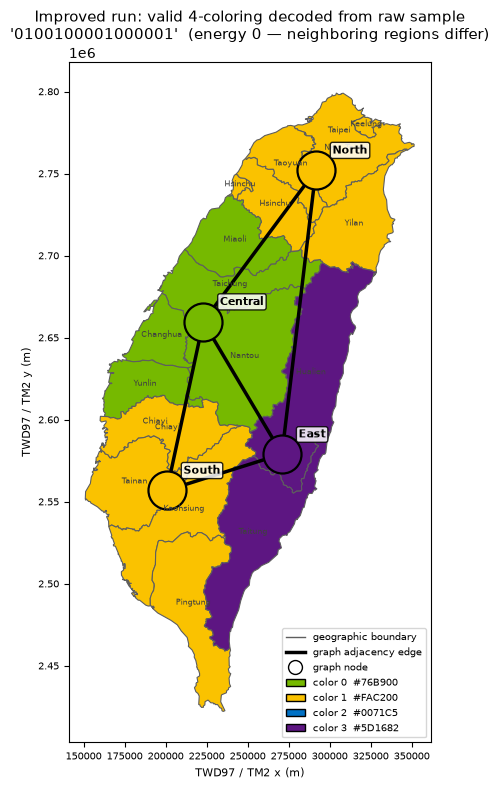

In [5]:
# Cell 5 — visualize on the map for the coloring.
best_coloring = result["assignment"]             # e.g. {"North": 1, "Central": 0, ...}
unit_colors = {}
for name, county in taiwan["counties"].items():  # paint every county with its region's color
    unit_colors[name] = hp.PALETTE[best_coloring[county["region"]]]
node_colors = {}
for region in hp.REGION_ORDER:
    node_colors[region] = hp.PALETTE[best_coloring[region]]

fig, ax = hp.plot_map(taiwan, unit_colors=unit_colors,
                      node_pos=hp.group_positions(taiwan, "region"), edges=EDGES,
                      node_colors=node_colors, unit_labels=True, color_legend=True,
                      title="Improved run: valid 4-coloring decoded from raw sample\n"
                            f"'{result['best']}'  (energy 0 — neighboring regions differ)")
plt.show()

## 5 · What you should take away

1. **The optimizer is a free lunch at this scale.** Same circuit, same budget — swapping COBYLA
   for Nelder–Mead cut the energy dramatically and multiplied the valid-coloring rate. Always
   try more than one optimizer before tuning anything else.
2. **Environment variables are read at import time.** Set them at the very top, before
   `import cudaq`, and restart the kernel to change them.

Next, the problem grows. At full county resolution (19 nodes × 4 colors = 76 qubits) a state
vector would need $2^{76} \times 8$ bytes ≈ $6\times10^{23}$ bytes — impossible. Even grouped
into 9 zones (36 qubits), it would need $2^{36} \times 8$ bytes = 550 GB — more than any single
GPU today. Notebook 02's answer: **tensor networks**, a different way of representing the
quantum state that sidesteps the giant vector entirely.